<a href="https://colab.research.google.com/github/mzaib1012/Automated-Requirements-Traceability-Engine/blob/main/notebooks/requirements_traceability_engine.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

📝 Systems Engineering data baselines compiled and exported successfully.

🚨 COMPLIANCE MATRIX REPORT GENERATION ENGINE
✅ [COMPLIANT] REQ-001 (System Power Supply): VERIFIED - Linked to active plan TP-PWR-01 (PASSED)
❌ [RED-FLAG] REQ-002 (Overcurrent Protection): UNVERIFIED - No hardware test plan mapping exists!
✅ [COMPLIANT] REQ-003 (MIMO Antenna Array): VERIFIED - Linked to active plan TP-TEL-05 (PASSED)
⚠️  [WARNING]  REQ-004 (Thermal Dissipation): FAILED TRACE - Linked to failing plan TP-THERM-02!
❌ [RED-FLAG] REQ-005 (Emergency Cutoff): UNVERIFIED - No hardware test plan mapping exists!


/tmp/ipykernel_1640/741263847.py:99: UserWarning: Setting the 'color' property will override the edgecolor or facecolor properties.
  handles = [plt.Rectangle((0,0),1,1, color=c, edgecolor='black', alpha=0.8) for c in labels.keys()]


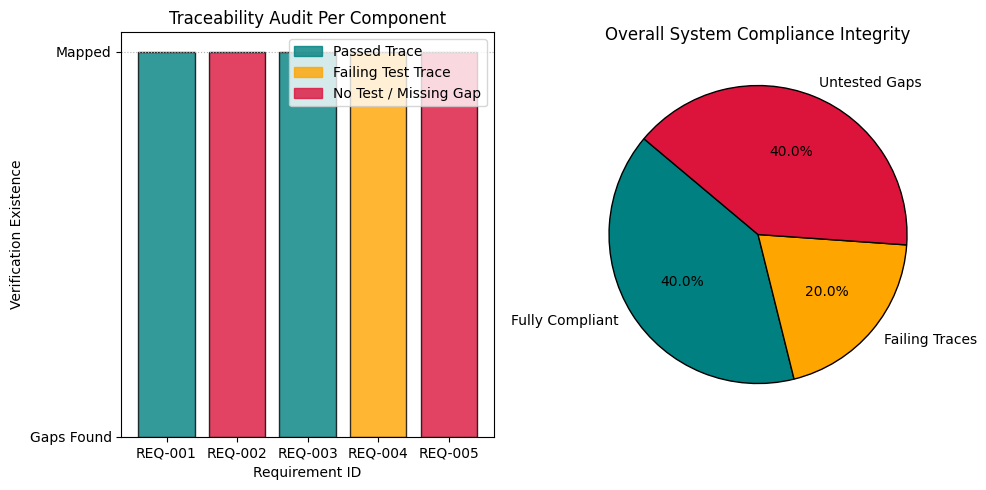

In [1]:
import pandas as pd
import re
import matplotlib.pyplot as plt

# --- 1. Programmatically Generate System Requirements & Test Logs ---
# This simulates raw system documentation exported from engineering tools like DOORS or Excel

sys_reqs_data = {
    'Requirement_ID': ['REQ-001', 'REQ-002', 'REQ-003', 'REQ-004', 'REQ-005'],
    'Title': ['System Power Supply', 'Overcurrent Protection', 'MIMO Antenna Array', 'Thermal Dissipation', 'Emergency Cutoff'],
    'Description': [
        'The system shall operate within a stable voltage input range of 12V to 24V DC.',
        'Hardware must trip and cut input rail connection if current draw exceeds 5.0 Amps.',
        'The transceiver module shall integrate a 10x10 antenna array configuration.',
        'The enclosure cooling architecture must maintain internal junction temperatures below 85C.',
        'A physical hardware line-break switch must instantly disconnect the battery pack upon actuation.'
    ]
}

hw_test_data = {
    'Test_Plan_ID': ['TP-PWR-01', 'TP-TEL-05', 'TP-THERM-02'],
    'Test_Name': ['Voltage Range Sweep Validation', 'RF CSI Signature Target Verification', 'Dynamic Burn-In Thermal Profile'],
    'Traceable_Refs': ['Validates REQ-001 functional logic.', 'Designed for REQ-003 validation.', 'Executes compliance mapping for REQ-004 specs.'],
    'Status': ['PASSED', 'PASSED', 'FAILED']
}

df_reqs = pd.DataFrame(sys_reqs_data)
df_tests = pd.DataFrame(hw_test_data)

# Export to CSV formats inside Colab environment to simulate parsing external documents
df_reqs.to_csv('system_requirements.csv', index=False)
df_tests.to_csv('hardware_test_plan.csv', index=False)

print("📝 Systems Engineering data baselines compiled and exported successfully.\n")

# --- 2. Traceability Compilation & Parsing Engine ---
def extract_req_ids(text):
    # Uses regular expressions to scan engineering notes for matching IDs (e.g., REQ-001)
    match = re.search(r'REQ-\d+', text)
    return match.group(0) if match else None

# Load files through parser
reqs_input = pd.read_csv('system_requirements.csv')
tests_input = pd.read_csv('hardware_test_plan.csv')

# Parse structural reference links using regex
tests_input['Mapped_Req_ID'] = tests_input['Traceable_Refs'].apply(extract_req_ids)

# Merge system requirements table with verification matrix paths using a Left Join
traceability_matrix = pd.merge(reqs_input, tests_input, left_on='Requirement_ID', right_on='Mapped_Req_ID', how='left')

# --- 3. Verification Gap & Red-Flag Compliance Reporting ---
print("="*70)
print("🚨 COMPLIANCE MATRIX REPORT GENERATION ENGINE")
print("="*70)

verification_summary = []
unverified_count = 0
failed_count = 0
passed_count = 0

for idx, row in traceability_matrix.iterrows():
    req_id = row['Requirement_ID']
    title = row['Title']
    tp_id = row['Test_Plan_ID']
    status = row['Status']

    if pd.isna(tp_id):
        print(f"❌ [RED-FLAG] {req_id} ({title}): UNVERIFIED - No hardware test plan mapping exists!")
        verification_summary.append({'ID': req_id, 'Status': 'UNVERIFIED', 'Color': 'crimson'})
        unverified_count += 1
    elif status == 'FAILED':
        print(f"⚠️  [WARNING]  {req_id} ({title}): FAILED TRACE - Linked to failing plan {tp_id}!")
        verification_summary.append({'ID': req_id, 'Status': 'FAILED', 'Color': 'orange'})
        failed_count += 1
    else:
        print(f"✅ [COMPLIANT] {req_id} ({title}): VERIFIED - Linked to active plan {tp_id} ({status})")
        verification_summary.append({'ID': req_id, 'Status': 'PASSED', 'Color': 'teal'})
        passed_count += 1

print("="*70)

# --- 4. Quality Metric Profile Visualization ---
df_summary = pd.DataFrame(verification_summary)

plt.figure(figsize=(10, 5))

# Plot 1: Bar chart mapping specific requirements structural integrity status
plt.subplot(1, 2, 1)
bars = plt.bar(df_summary['ID'], [1]*len(df_summary), color=df_summary['Color'], edgecolor='black', alpha=0.8)
plt.title('Traceability Audit Per Component')
plt.ylabel('Verification Existence')
plt.xlabel('Requirement ID')
plt.yticks([0, 1], ['Gaps Found', 'Mapped'])
plt.grid(axis='y', linestyle=':')

# Custom Legend Mapping
labels = {'teal': 'Passed Trace', 'orange': 'Failing Test Trace', 'crimson': 'No Test / Missing Gap'}
handles = [plt.Rectangle((0,0),1,1, color=c, edgecolor='black', alpha=0.8) for c in labels.keys()]
plt.legend(handles, labels.values())

# Plot 2: Global System Compliance Breakdown
plt.subplot(1, 2, 2)
metrics = [passed_count, failed_count, unverified_count]
categories = ['Fully Compliant', 'Failing Traces', 'Untested Gaps']
colors = ['teal', 'orange', 'crimson']

# Clear out 0 elements if any to keep pie chart structure valid
active_metrics = [m for m in metrics if m > 0]
active_categories = [categories[i] for i, m in enumerate(metrics) if m > 0]
active_colors = [colors[i] for i, m in enumerate(metrics) if m > 0]

plt.pie(active_metrics, labels=active_categories, colors=active_colors, autopct='%1.1f%%', startangle=140,
        wedgeprops={'edgecolor':'black','linewidth': 1, 'antialiased': True})
plt.title('Overall System Compliance Integrity')

plt.tight_layout()
plt.savefig('requirements_traceability_report.png', dpi=300)
plt.show()